<a href="https://colab.research.google.com/github/DawerSP/Inteligencia-Aritificial/blob/main/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

######K-means

Práctica

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["figure.figsize"]=(16,9)
plt.style.use("ggplot")

In [13]:
dataframe=pd.read_csv(r"/content/analisis.csv")
dataframe.head()

,usuario,op,co,ex,ag,ne,wordcount,categoria
0,3gerardpique,34.297953,28.148819,41.948819,29.370315,9.841575,37.0945,7
1,aguerosergiokun,44.986842,20.525865,37.938947,24.279098,10.362406,78.7970,7
2,albertochicote,41.733854,13.745417,38.999896,34.645521,8.836979,49.2604,4
3,AlejandroSanz,40.377154,15.377462,52.337538,31.082154,5.032231,80.4538,2
4,alfredocasero1,36.664677,19.642258,48.530806,31.138871,7.305968,47.0645,4


In [14]:
dataframe.groupby("categoria").size()

,0
categoria,
1,27
2,34
3,9
4,19
5,4
6,8
7,17
8,16
9,6


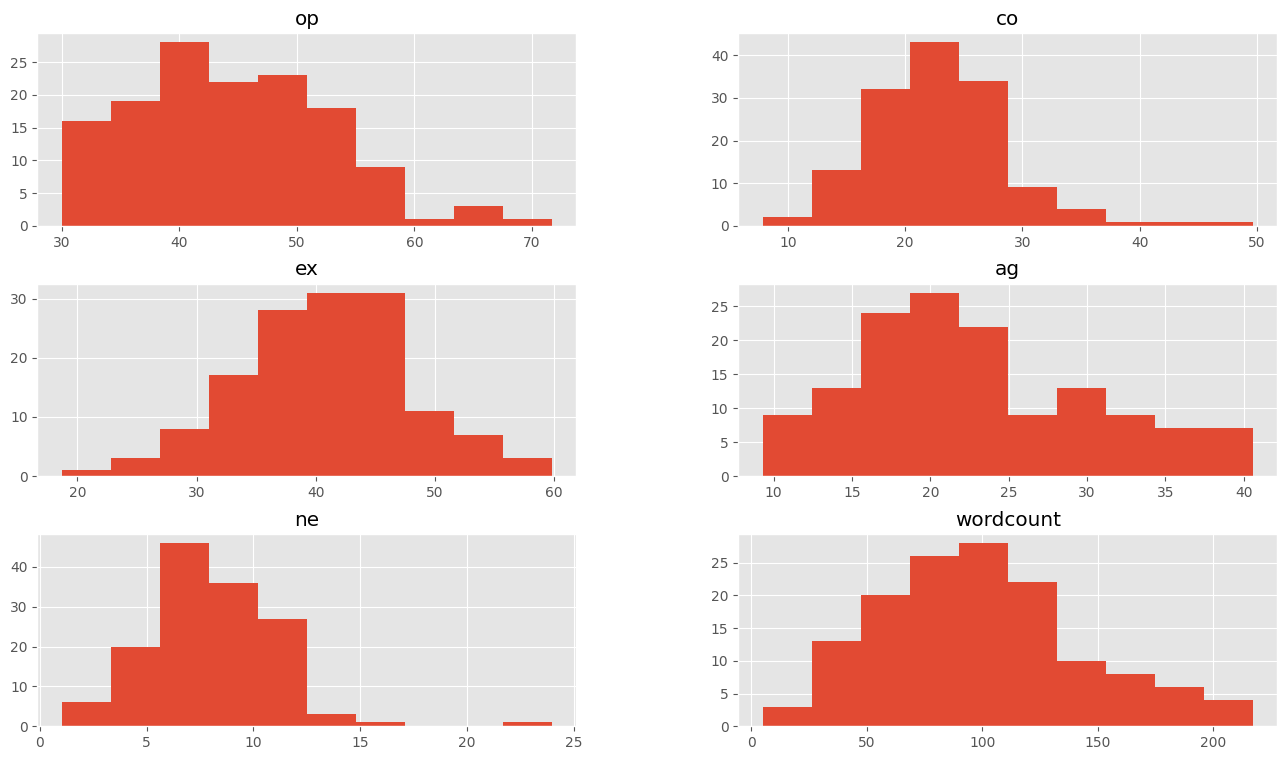

In [15]:
dataframe.drop(columns=["categoria"]).hist()
plt.show()

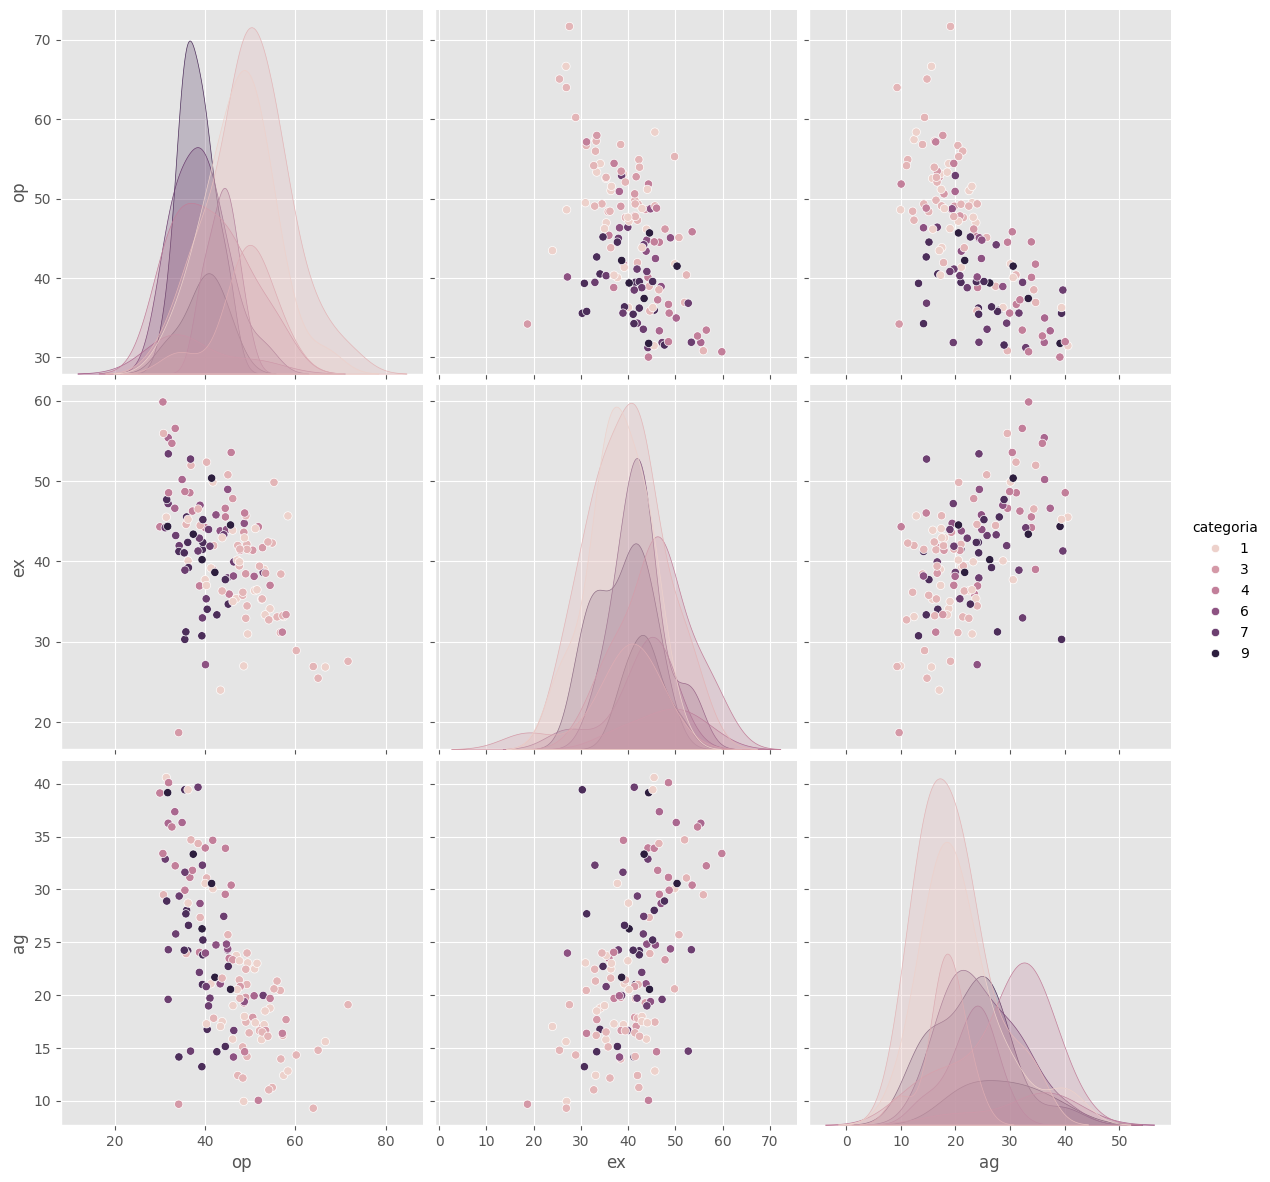

In [16]:
sb.pairplot(dataframe.dropna(),hue="categoria",height=4,vars=["op","ex","ag"],kind="scatter")

In [17]:
X=np.array(dataframe[["op","ex","ag"]])
Y=np.array(dataframe["categoria"])
X.shape

(140, 3)

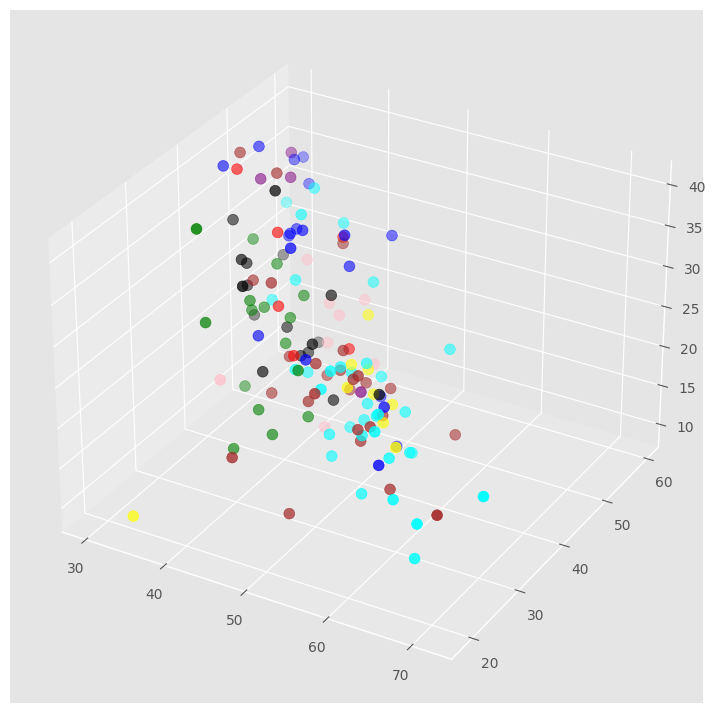

In [19]:
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
colores=["orange","brown","cyan","yellow","blue","purple","pink","black","green","red"]
asignar=[]
for row in Y:
  asignar.append(colores[row])
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar,s=60)
plt.show()

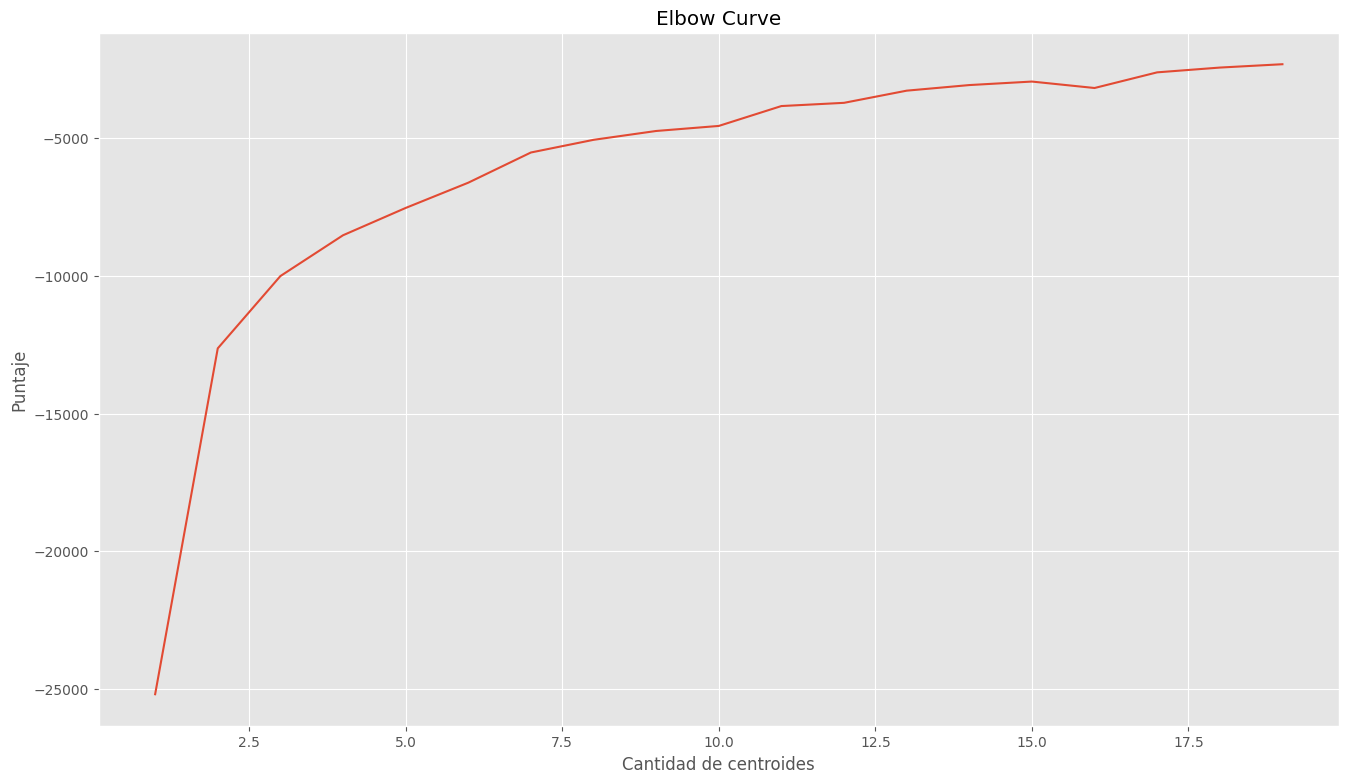

In [26]:
Nc=range(1,20)
kmeans=[KMeans(n_clusters=i) for i in Nc]
kmeans
score=[kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(Nc,score)
plt.xlabel("Cantidad de centroides")
plt.ylabel("Puntaje")
plt.title("Elbow Curve")
plt.show()

In [28]:
kmeans=KMeans(n_clusters=5).fit(X)
centroides=kmeans.cluster_centers_
print(centroides)

[[39.97218127 43.72339913 23.06515427]
 [57.63426538 32.95310414 15.51772971]
 [35.5903695  41.09293906 34.99064133]
 [47.54392581 38.25998696 18.4145571 ]
 [36.61299584 51.26897505 31.75676037]]


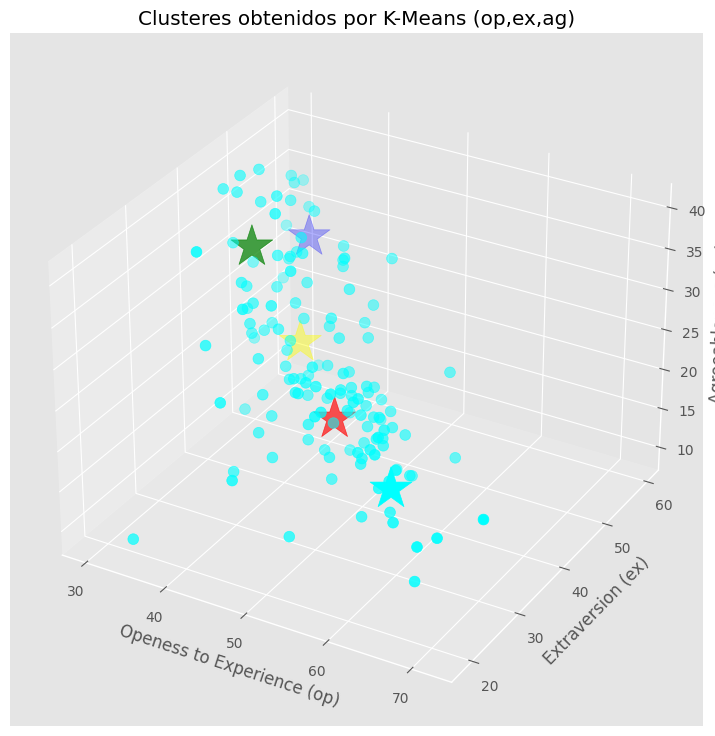

In [31]:
labels=kmeans.predict(X)
C=kmeans.cluster_centers_
colores=["yellow","cyan","green","red","blue"]
asignar=[]
for now in labels:
  asignar.append(colores[row])

fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar,s=60)
ax.scatter(C[:,0],C[:,1],C[:,2],marker="*",color=colores,s=1000)
ax.set_xlabel("Openess to Experience (op)")
ax.set_ylabel("Extraversion (ex)")
ax.set_zlabel("Agreeableness (ag)")
ax.set_title("Clusteres obtenidos por K-Means (op,ex,ag)")
plt.show()

Text(0.5, 1.0, 'op vs ex')

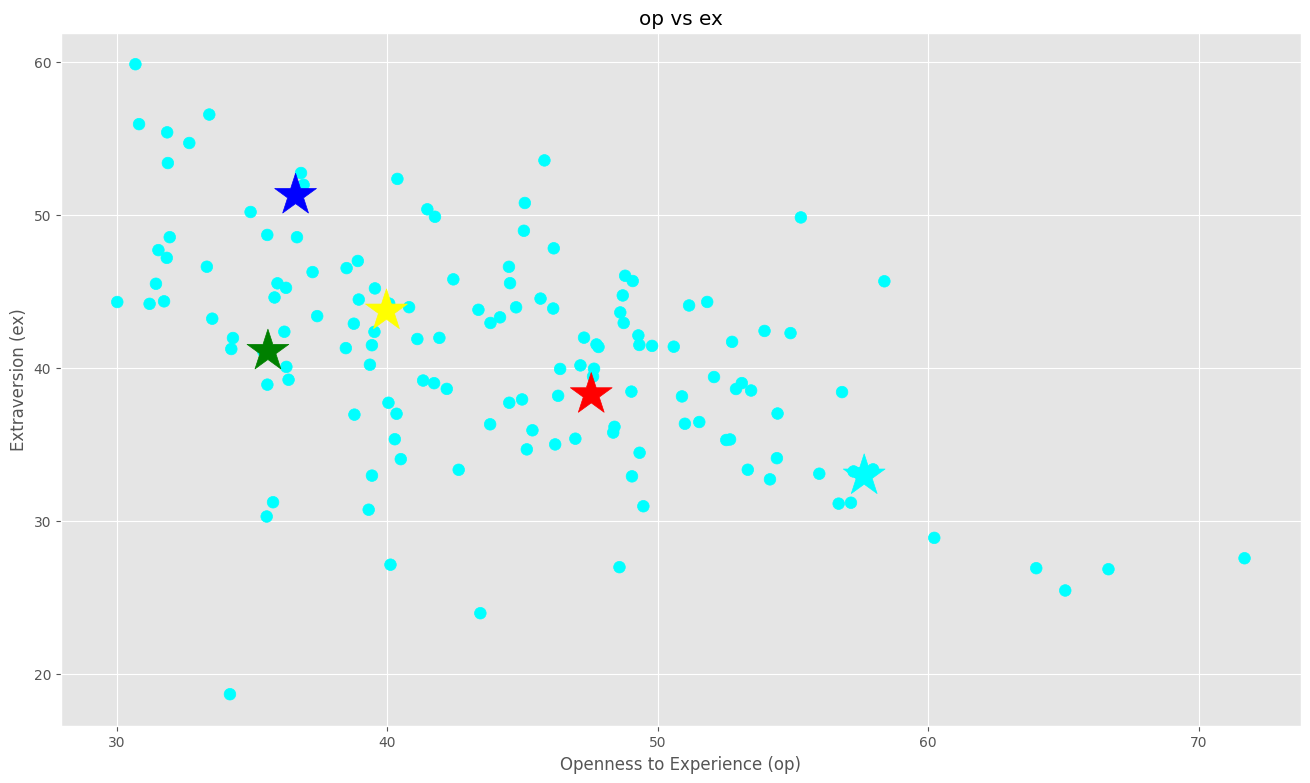

In [39]:
f1=dataframe["op"].values
f2=dataframe["ex"].values




plt.scatter(f1,f2,c=asignar,s=70)
plt.scatter(C[:,0],C[:,1],marker="*",c=colores,s=1000)
plt.xlabel("Openness to Experience (op)")
plt.ylabel("Extraversion (ex)")
plt.title("op vs ex")


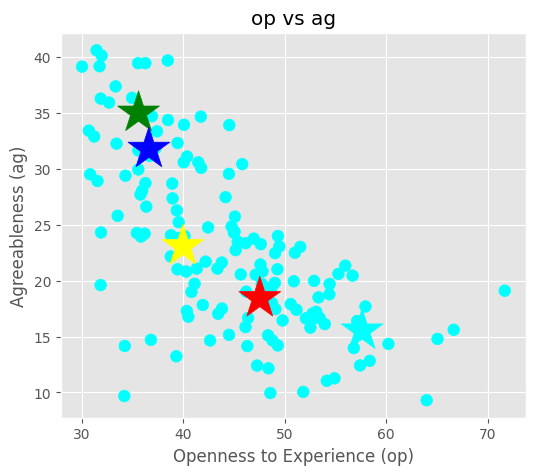

In [40]:
plt.figure(figsize=(6, 5))
plt.scatter(f1, f3, c=asignar, s=70)
plt.scatter(C[:, 0], C[:, 2], marker="*", c=colores, s=1000)
plt.xlabel("Openness to Experience (op)")
plt.ylabel("Agreeableness (ag)")
plt.title("op vs ag")
plt.show()

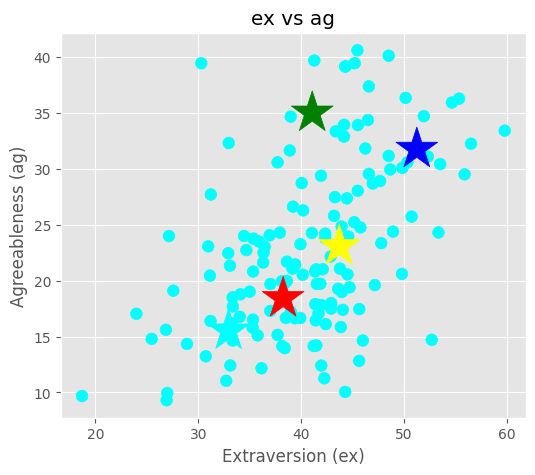

In [41]:
plt.figure(figsize=(6, 5))
plt.scatter(f2, f3, c=asignar, s=70)
plt.scatter(C[:, 1], C[:, 2], marker="*", c=colores, s=1000)
plt.xlabel("Extraversion (ex)")
plt.ylabel("Agreeableness (ag)")
plt.title("ex vs ag")
plt.show()

In [33]:
copy=pd.DataFrame()
copy["usuario"]=dataframe["usuario"].values
copy["categoria"]=dataframe["categoria"].values
copy["label"]=labels;
cantidadGrupo=pd.DataFrame()
cantidadGrupo["Color"]=colores
cantidadGrupo["cantidad"]=copy.groupby("label").size()
cantidadGrupo

,Color,cantidad
0,yellow,30
1,cyan,21
2,green,18
3,red,52
4,blue,19


In [42]:
group_referrer_index=copy["label"]==0
group_referrals=copy[group_referrer_index]

diversidadGrupo=pd.DataFrame()
diversidadGrupo["categoria"]=[0,1,2,3,4,5,6,7,8,9]
diversidadGrupo["cantidad"]=group_referrals.groupby("categoria").size()
diversidadGrupo

,categoria,cantidad
0,0,NaN
1,1,1.0
2,2,4.0
3,3,1.0
4,4,2.0
5,5,NaN
6,6,4.0
7,7,7.0
8,8,8.0
9,9,3.0


In [49]:
closest,_= pairwise_distances_argmin_min(kmeans.cluster_centers_,X)
closest

array([ 64,  75, 111,  29,   4])

In [50]:
user=dataframe["usuario"].values
for row in closest:
  print(user[row])

ierrejon
JLo
perezreverte
CindyCrawford
alfredocasero1


In [54]:
X_new=np.array([[45.92,57.74,15.66]])

new_labels=kmeans.predict(X_new)
print(new_labels)

[0]
